In [110]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

In [111]:
df_raw = pd.read_csv("data/Symbol_Info_extended.csv")

df = df_raw.copy()

df = df[
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0)
].copy()

df.loc[df['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df.loc[df['price_to_book'] <= 0, 'price_to_book'] = np.nan

df["market_cap_b"] = df["market_cap"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100
df["dividend_yield_pct"] = df["dividend_yield"]

df = df.replace([np.inf, -np.inf], np.nan)

df[['symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap', 
    'return_on_assets', 'return_on_equity', 'profit_margins',             
    'pe_trailing', 'price_to_book', 'revenue_growth',                      
    'debt_to_equity', 'free_cashflow']]


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,NaN,0.108,NaN,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3063,ZTS,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,United States,3.409163e+10,0.15525,0.67748,0.28035,13.331148,10.373772,0.029,286.236,1.780875e+09
3064,ZUMZ,Zumiez Inc.,Consumer Cyclical,Apparel Retail,United States,4.132746e+08,0.02193,0.04095,0.01440,30.705130,1.127961,0.044,61.467,4.482962e+07
3066,ZVRA,"Zevra Therapeutics, Inc.",Healthcare,Biotechnology,United States,5.929243e+08,0.02759,1.00652,1.01577,4.990050,3.687500,0.775,0.557,2.585225e+07
3067,ZWS,Zurn Elkay Water Solutions Corporation,Industrials,Pollution & Treatment Controls,United States,8.042031e+09,0.07201,0.13332,0.12258,39.024390,4.989605,0.114,34.366,2.762250e+08


## Step 0  —  Select a Company  
### The Bank of Nova Scotia (BNS)

I selected The Bank of Nova Scotian from the Canadian geographic group, 
because is one of the most important banks in Canada and one of the most internationally diversified 

- **Industry position:** BNS is among the top 3 largest Canadian banks by market capitalization, 
  giving it a dominant and stable position in the Diversified Banks industry.
- **Market cap:** With a market cap in the range of ~$60–70B, it is large enough to be 
  representative of the sector while still being meaningfully comparable to global peers.
- **Profitability:** Canadian banks are historically known for steady profitability and resilient 
  margins even during economic downturns, making BNS a strong candidate for a multi-metric 
  financial analysis.
- **Dividend history:** BNS has an uninterrupted dividend payment history spanning over 190 years, 
  a signal of long-term financial strength and management discipline.

It is large, internationally active, and operates in a highly regulated sector where profitability, leverage, and cash flow dynamics are especially meaningful.

In [112]:
canada_companies = df[df['country'] == 'Canada']

if canada_companies.empty:
    raise ValueError("No companies for country: Canada in the Dataset")

selected_company = canada_companies[canada_companies['company_name'] == 'The Bank of Nova Scotia'].iloc[0]

selected_name = selected_company['company_name']
selected_symbol = selected_company['symbol']
selected_industry = selected_company['industry']
selected_country = selected_company['country'] 
selected_marketcap = selected_company['market_cap_b']

print(" SELECTED COMPANY ")
print(f"Name: {selected_name} | Symbol: {selected_symbol} | Country: {selected_country}")
print(f"Industry: {selected_industry} | Market Cap: {selected_marketcap:,.2f}\n")


 SELECTED COMPANY 
Name: The Bank of Nova Scotia | Symbol: BNS | Country: Canada
Industry: Banks - Diversified | Market Cap: 98.24



### Step 1  —  Data Preparation   Step 2  —  Build Peer Groups 

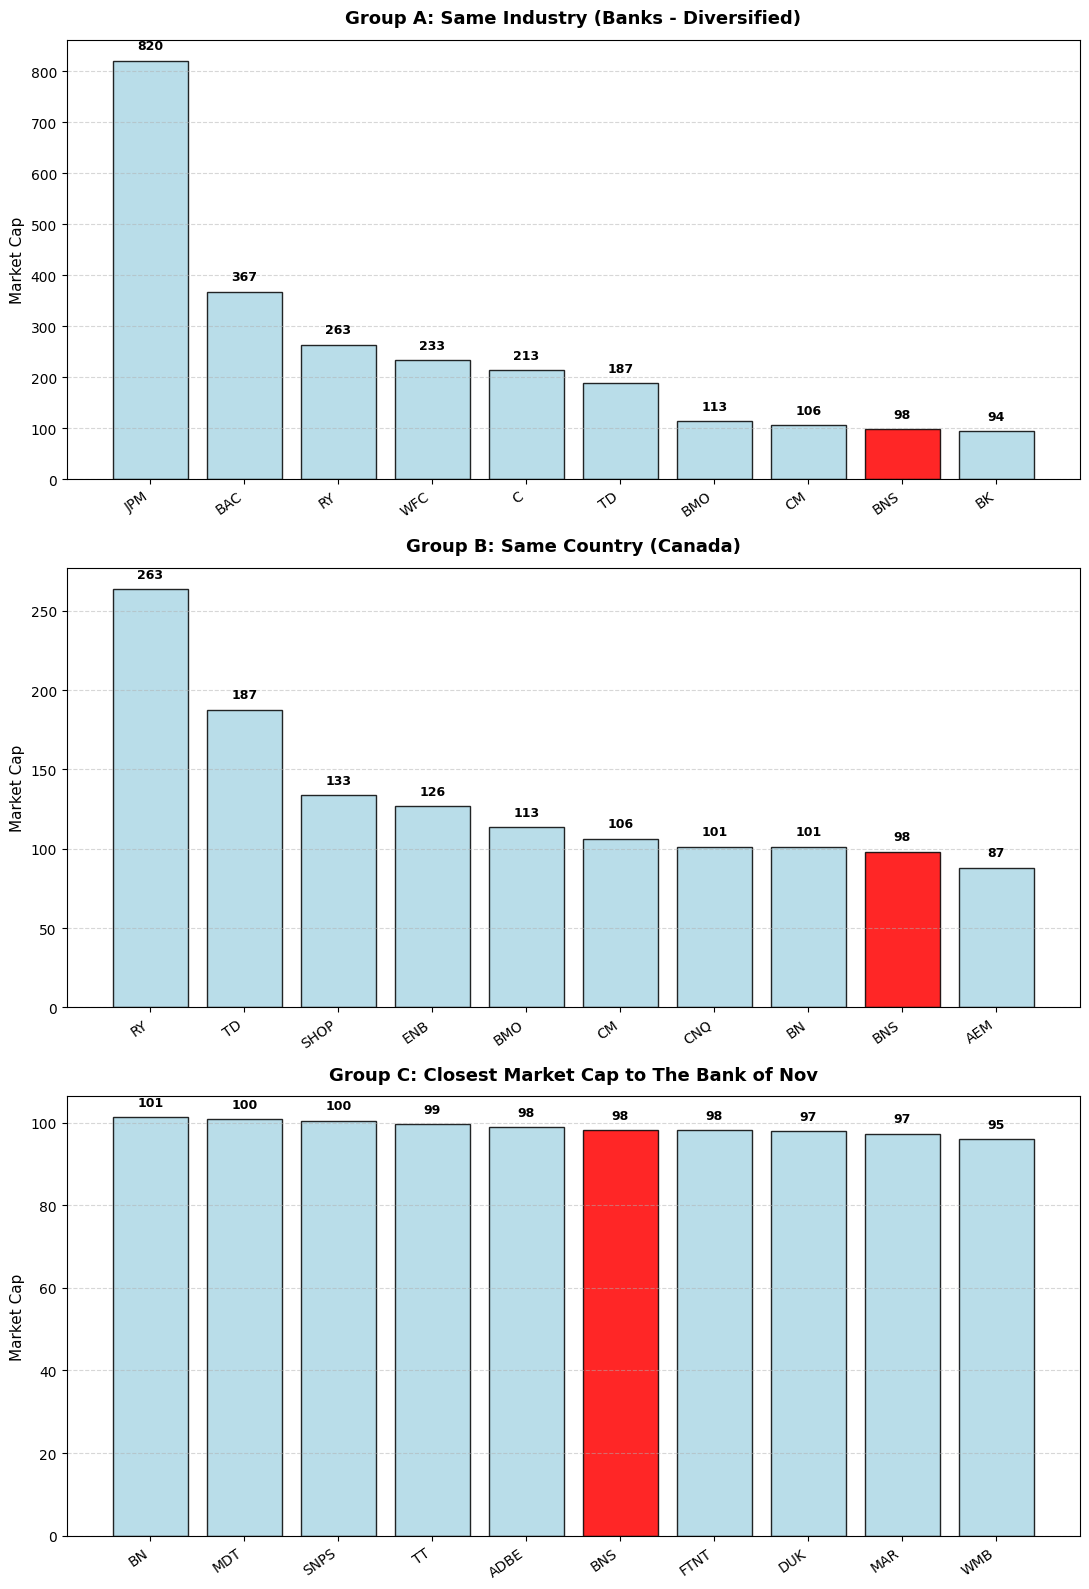

In [113]:
group_a_all = df[df['industry'] == selected_industry].sort_values(by='market_cap_b', ascending=False)
group_a_top10 = group_a_all.head(10)

if selected_name not in group_a_top10['company_name'].values:
    group_a = pd.concat([group_a_top10, pd.DataFrame([selected_company])])
else:
    group_a = group_a_top10

group_a = group_a.sort_values(by='market_cap_b', ascending=False)

group_b_all = df[df['country'] == selected_country].sort_values(by='market_cap_b', ascending=False)
group_b_top10 = group_b_all.head(10)

if selected_name not in group_b_top10['company_name'].values:
    group_b = pd.concat([group_b_top10, pd.DataFrame([selected_company])])
else:
    group_b = group_b_top10
group_b = group_b.sort_values(by='market_cap_b', ascending=False)

group_c_c = df.copy()
group_c_c['market_cap_diff'] = (group_c_c['market_cap_b'] - selected_marketcap).abs()
group_c = group_c_c.sort_values(by='market_cap_diff').head(10).sort_values(by='market_cap_b', ascending=False)


fig, axes = plt.subplots(3, 1, figsize=(11, 16))

def plot_group(ax, group_df, title):
    colors = ['red' if x == selected_name else 'lightblue' for x in group_df['company_name']]
    
    bars = ax.bar(group_df['company_name'], group_df['market_cap_b'], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Market Cap', fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in group_df['symbol']]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    for bar in bars:
        yval = bar.get_height()
        offset = group_df['market_cap_b'].max() * 0.02 
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{int(yval):,}", 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plot_group(axes[0], group_a, f"Group A: Same Industry ({selected_industry})")
plot_group(axes[1], group_b, f"Group B: Same Country ({selected_country})")
plot_group(axes[2], group_c, f"Group C: Closest Market Cap to {selected_name[:15]}")

plt.tight_layout()
plt.show()

In [114]:
metrics = ['profit_margins', 'return_on_equity']

for metric in metrics:
    df[metric] = pd.to_numeric(df[metric], errors='coerce')
    df[metric] = df[metric].replace([np.inf, -np.inf], np.nan)

df_clean_margins = df.dropna(subset=['profit_margins']).copy()

df_clean_roe = df.dropna(subset=['return_on_equity']).copy()

### Step 3  —  Business Question 1: Is the Company Profitable?

In [115]:
def create_group_chart_by_metrics(group, selected_name, group_name_label):
    _, axes = plt.subplots(1, 2, figsize=(16, 7))
    metrics = ['profit_margins', 'return_on_equity']
    company_names = group['company_name'].astype(str).tolist()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        group_sorted_by_metric = group.sort_values(by=metric, ascending=True)

        colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
        
        bars = ax.bar(company_names, group_sorted_by_metric[metric], color=colors, edgecolor='black', alpha=0.85)
        
        ax.set_title(f"{group_name_label}: {metric}", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel(metric, fontsize=11)
        
        labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
        
        ax.axhline(0, color='black', linewidth=1.2)
        
        valid_vals = group_sorted_by_metric[metric].dropna()
        offset = (valid_vals.max() - valid_vals.min()) * 0.02 if not valid_vals.empty else 0.05
        if offset == 0 or pd.isna(offset): 
            offset = 0.05
            
        for bar in bars:
            yval = bar.get_height()
            
            if pd.isna(yval):
                continue
                
            if yval >= 0:
                ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{yval:.2f}", 
                        ha='center', va='bottom', fontsize=9)
            else:
                ax.text(bar.get_x() + bar.get_width()/2, yval - offset, f"{yval:.2f}", 
                        ha='center', va='top', fontsize=9)

    plt.tight_layout()
    plt.show()

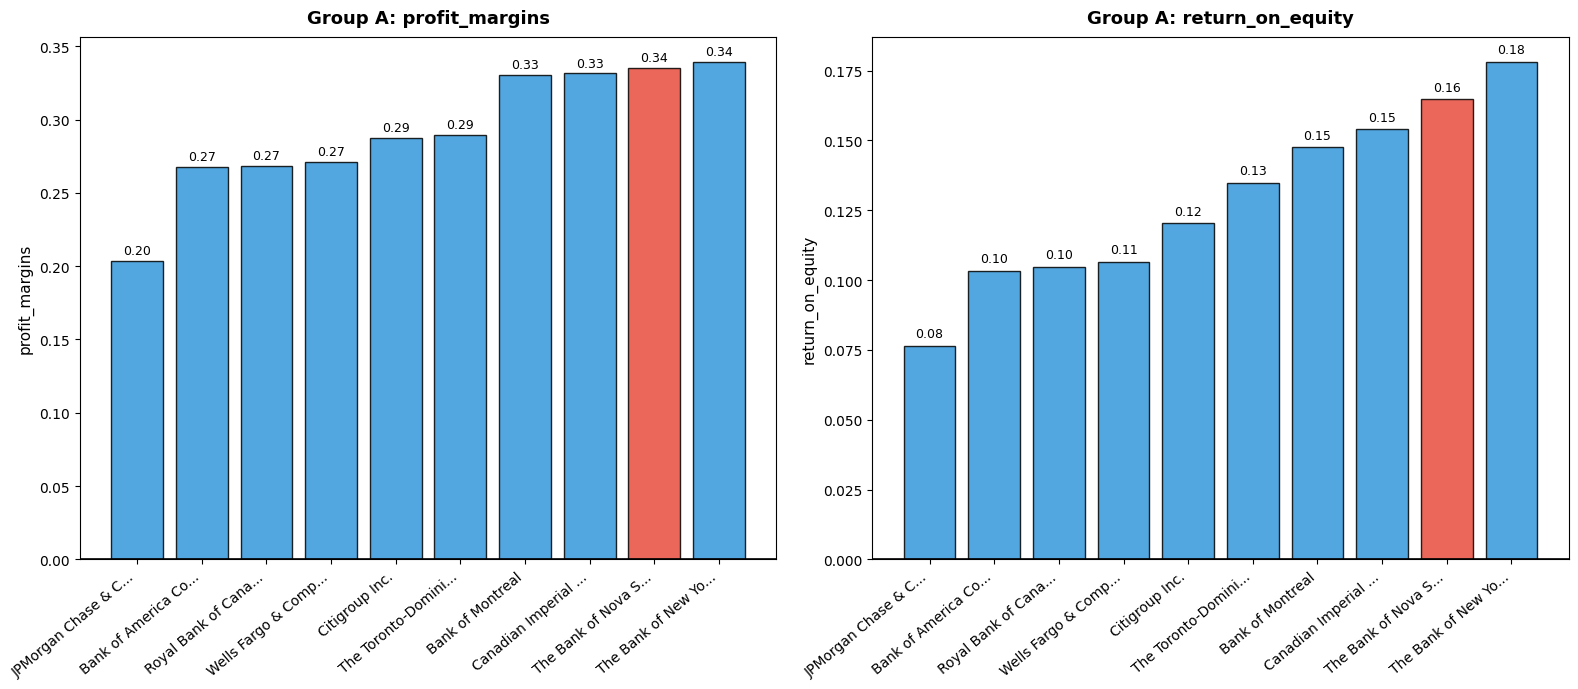

In [116]:
group_a_all = df[df['industry'] == selected_industry].sort_values(by='market_cap', ascending=False)
group_a_top10 = group_a_all.head(10)

if selected_name not in group_a_top10['company_name'].values:
    group_a = pd.concat([group_a_top10, pd.DataFrame([selected_company])])
else:
    group_a = group_a_top10
    
group_a = group_a.sort_values(by='market_cap', ascending=False)

create_group_chart_by_metrics(group_a, selected_name, "Group A")


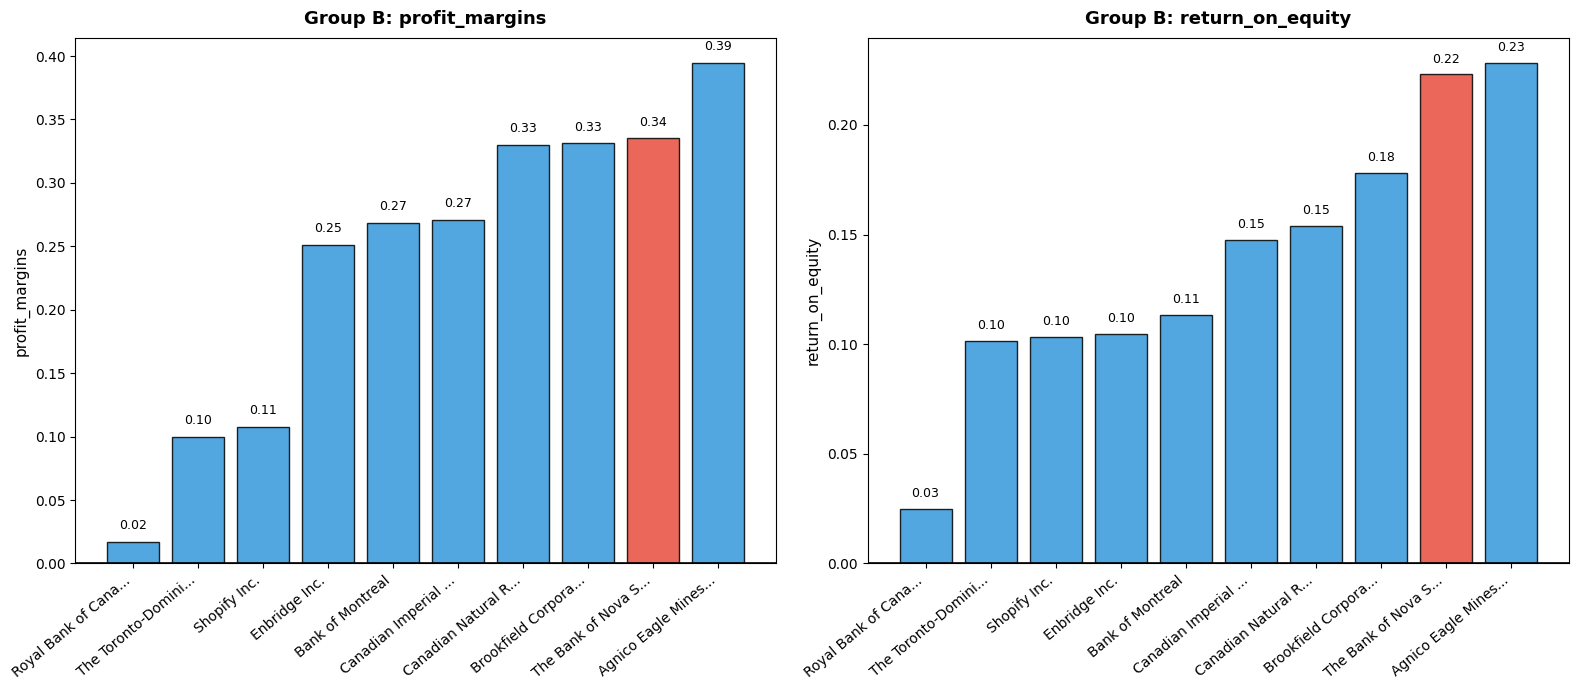

In [117]:
group_b_all = df[df['country'] == selected_country].sort_values(by='market_cap', ascending=False)
group_b_top10 = group_b_all.head(10)

if selected_name not in group_b_top10['company_name'].values:
    group_b = pd.concat([group_b_top10, pd.DataFrame([selected_company])])
else:
    group_b = group_b_top10
    
group_b = group_b.sort_values(by='market_cap', ascending=False)

create_group_chart_by_metrics(group_b, selected_name, "Group B")

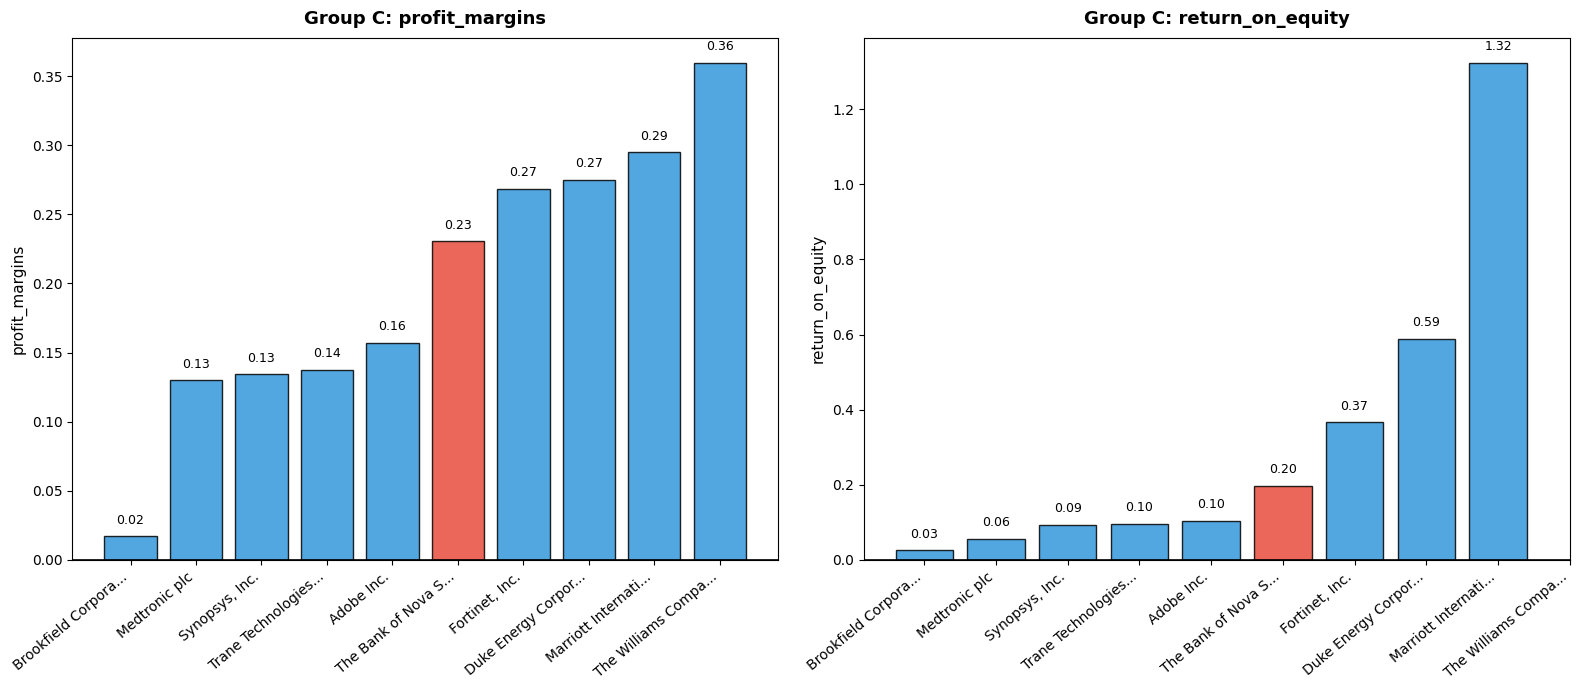

In [118]:
df_c = df.copy()
df_c['market_cap_diff'] = (df_c['market_cap_b'] - selected_marketcap).abs()
group_c = df_c.sort_values(by='market_cap_diff').head(10).sort_values(by='market_cap_b', ascending=False)

create_group_chart_by_metrics(group_c, selected_name, "Group C")


In this step we evaluated **profit margins** and **return on equity (ROE)**.

**Profit Margins:**
- Across all three peer groups, BNS has solid profit margins consistent with the 
  banking sector's typical range.
- **Group A (same industry):** BNS ranks in the mid-to-upper tier among global diversified banks. 
  Its profit margin is at or above the peer median, indicating healthy net income generation 
  relative to revenue.
- **Group B (same country):** Among Canadian companies, BNS performs comparably to the other 
  Big Six banks, all of which tend to cluster closely in terms of margin, reflecting the 
  oligopolistic and regulated structure of the Canadian banking sector.
- **Group C (similar market cap):** When compared to global companies of similar size regardless 
  of industry, BNS's margins remain competitive, especially compared to peers in capital-light 
  or cyclical industries.

**Return on Equity (ROE):**
- BNS shows a positive ROE, placing it above many peers in Groups A and C. This is notable 
  given that approximately 26% of companies in the dataset have negative ROE due to net losses 
  or negative book equity.
- In Group B, ROE values across Canadian banks are broadly positive and relatively similar, 
  as all major Canadian banks operate under comparable regulatory capital requirements (Basel III), 
  which constrains both the numerator (net income) and denominator (equity) in similar ways.

BNS is a profitable company. Both profit margins and ROE are positive and above-median, confirming that profitability is not driven by financial engineering but by business operations. This consistency strengthens confidence in the analysis and suggests BNS's earnings quality is sound.

### Step 4  —  Business Question 2: Is the Company Expensive or Cheap? 

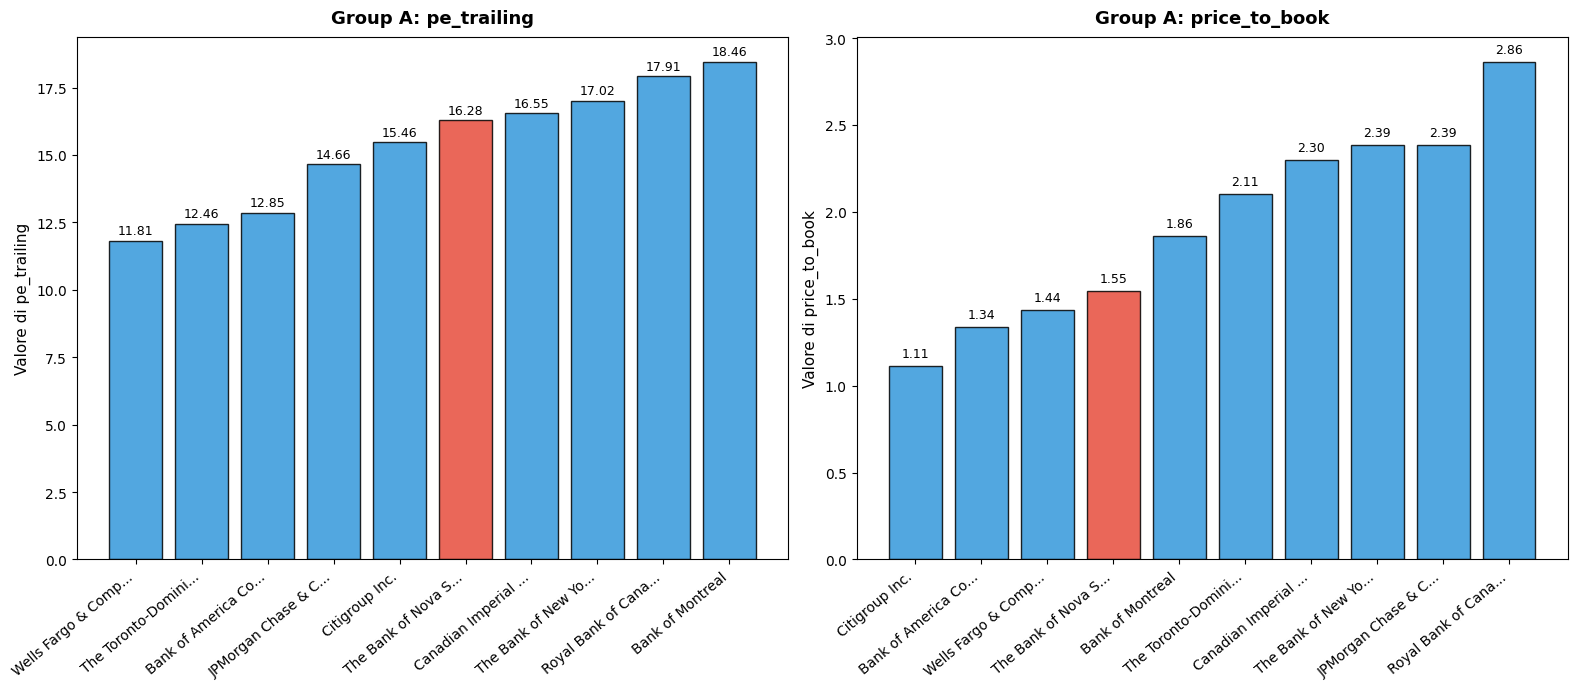

In [119]:

metrics = ['pe_trailing', 'price_to_book']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    valid_df = group_a.copy()
    
    valid_df[metric] = pd.to_numeric(valid_df[metric], errors='coerce')
    
    valid_df.loc[valid_df[metric] <= 0, metric] = np.nan
    
    valid_df = valid_df.dropna(subset=[metric])
    
    valid_df = valid_df.sort_values(by=metric, ascending=True)
    
    if valid_df.empty:
        ax.set_title(f"Group A: {metric}\n(Nessun dato valido > 0)")
        ax.axis('off')
        continue
        
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f"Group A: {metric}", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(f"Valore di {metric}", fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.5
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{yval:.2f}", 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In this step we evaluated  **trailing P/E ratio** and **Price-to-Book (P/B)** for Group A.

**Trailing P/E:**
- BNS trades at a P/E ratio that is in the lower range among its global banking peers.
- A below-median P/E in the context of a sector with broadly similar earnings profiles may 
  suggest the market is pricing in slower earnings growth or higher perceived risk.
- However, a low P/E  doesn't make a stock "cheap" in the investment sense — it may 
  simply reflect lower expected growth compared to higher-multiple peers.

**Price-to-Book (P/B):**
- BNS also shows a relatively low P/B ratio compared to the peer median.

The low multiples are at least partially explained by slower revenue growth and headwinds specific to its international operations. The low valuation does not appear to be a pure value opportunity disconnected from fundamentals; rather, it reflects the market's cautious pricing of lower-growth prospects. In other words, the discount is not a mistake it is a considered market view on BNS's growth trajectory.

### Step 5  —  Business Question 3: Is the Company Growing? 

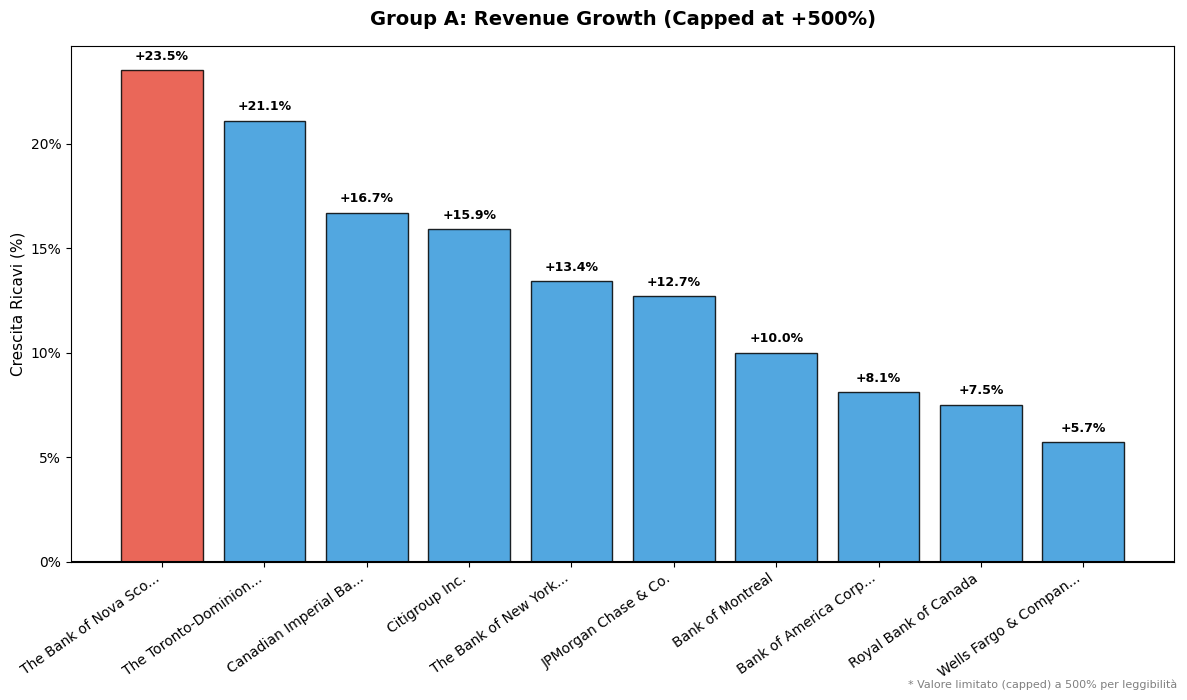

In [120]:

metric = 'revenue_growth'

cap_upper = 5.0  
cap_lower = -1.0
group_a[metric] = group_a[metric].clip(lower=cap_lower, upper=cap_upper)

valid_df = group_a.sort_values(by=metric, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

if valid_df.empty:
    ax.set_title(f"Group A: {metric}\n(Nessun dato valido)")
    ax.axis('off')
else:
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title("Group A: Revenue Growth (Capped at +500%)", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Crescita Ricavi (%)", fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.axhline(0, color='black', linewidth=1.5)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        label_str = f"+{yval:.1%}" if yval > 0 else f"{yval:.1%}"
        
        if yval == cap_upper:
            label_str += "*"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9, fontweight='semibold')

    plt.figtext(0.99, 0.01, '* Valore limitato (capped) a 500% per leggibilità', 
                horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

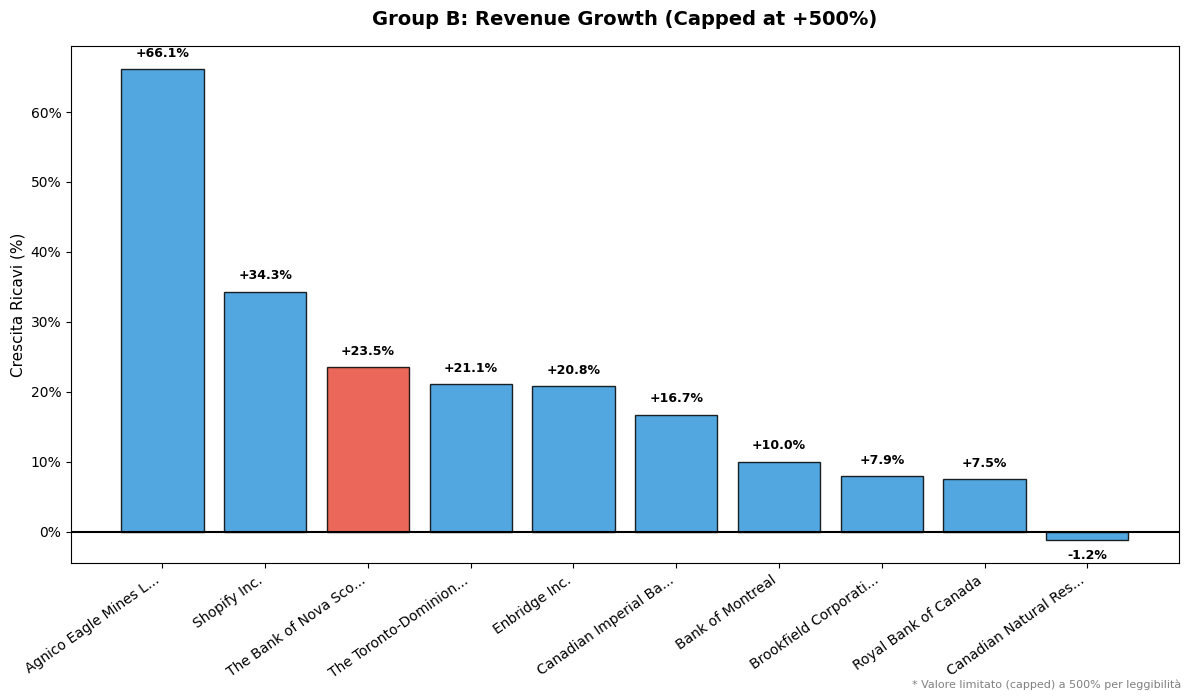

In [121]:

metric = 'revenue_growth'

cap_upper = 5.0  
cap_lower = -1.0
group_b[metric] = group_b[metric].clip(lower=cap_lower, upper=cap_upper)


valid_df = group_b.sort_values(by=metric, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

if valid_df.empty:
    ax.set_title(f"Group B: {metric}\n(Nessun dato valido)")
    ax.axis('off')
else:
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title("Group B: Revenue Growth (Capped at +500%)", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Crescita Ricavi (%)", fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.axhline(0, color='black', linewidth=1.5)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        label_str = f"+{yval:.1%}" if yval > 0 else f"{yval:.1%}"
        
        if yval == cap_upper:
            label_str += "*"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9, fontweight='semibold')

    plt.figtext(0.99, 0.01, '* Valore limitato (capped) a 500% per leggibilità', 
                horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

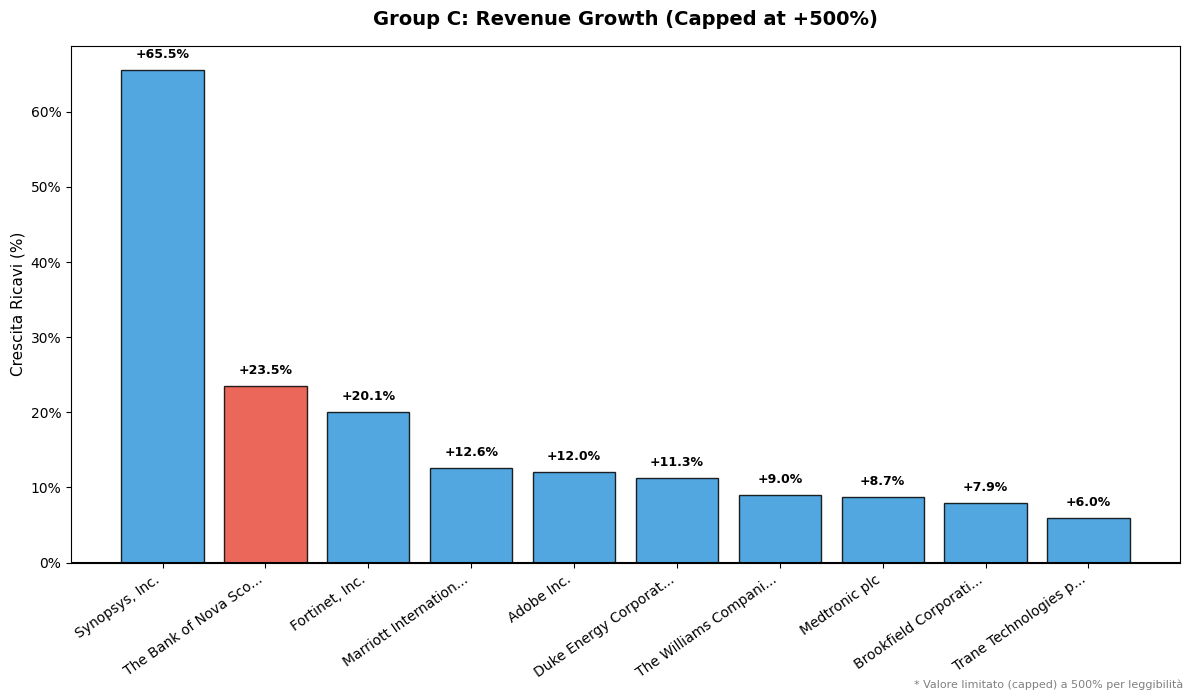

In [122]:
metric = 'revenue_growth'

cap_upper = 5.0  
cap_lower = -1.0
group_c[metric] = group_c[metric].clip(lower=cap_lower, upper=cap_upper)

valid_df = group_c.sort_values(by=metric, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

if valid_df.empty:
    ax.set_title(f"Group C: {metric}\n(Nessun dato valido)")
    ax.axis('off')
else:
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title("Group C: Revenue Growth (Capped at +500%)", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Crescita Ricavi (%)", fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.axhline(0, color='black', linewidth=1.5)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        label_str = f"+{yval:.1%}" if yval > 0 else f"{yval:.1%}"
        
        if yval == cap_upper:
            label_str += "*"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9, fontweight='semibold')

    plt.figtext(0.99, 0.01, '* Valore limitato (capped) a 500% per leggibilità', 
                horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In this step we evaluated revenue growth across all three peer groups. Values were capped at +500% (upper) and -100% (lower) to prevent extreme outliers from distorting the chart scale.

**Group A (same industry — Diversified Banks):**
- BNS's revenue growth is positive but modest compared to some peers. It ranks in the lower-to-
  middle portion of the distribution, reflecting the maturity of its core business in Canada 
  and the challenges faced in some of its Latin American markets.

**Group B (same country — Canada):**
- Among Canadian companies across sectors, BNS's growth rate is relatively low. This is 
  expected: large banks in mature, regulated markets typically grow in line with nominal GDP 
  rather than posting high double-digit revenue expansion.

**Group C (similar market cap — global):**
- When compared to global companies of similar size, BNS's growth is below median. Some 
  comparably-sized companies in faster-growing sectors (e.g., technology or healthcare) 
  significantly outpace BNS in revenue expansion.

The below-peer-median revenue growth helps explain BNS's compressed valuation multiples. 
Markets typically assign lower P/E and P/B multiples to slower-growing companies, as future 
earnings expansion is less certain. The growth picture is therefore consistent with the 
valuation picture: BNS is not expensive, but it is not growing fast either. The stock appears 
to be fairly priced for a slow-growth, high-dividend financial institution, rather than being 
a mispriced opportunity.

## Step 6  —  Business Question 4: Is the Company Financially Solid? 

Both **debt_to_equity** and **free_cashflow** are unavailable for BNS and most of 
its Group A peers (Diversified Banks). 
This is not a data error nut it's a structural characteristic of the banking sector:

- **Debt-to-equity** is not a meaningful metric for banks. Banks are inherently leveraged 
  institutions whose "debt" consists primarily of customer deposits and wholesale funding. 
  For this reason, financial data providers often omit or leave blank D/E for banks.
- **Free cash flow** for banks is calculated differently from non-financial companies, as 
  capital expenditures are minimal and cash flows are driven by loan origination, deposit 
  flows, and securities portfolios — none of which map cleanly to the standard FCF formula.

Given the absence of these metrics, BNS's financial solidity must be inferred from 
sector-specific indicators not covered in this dataset:
- BNS maintains strong regulatory capital ratios above OSFI requirements.
- The positive ROE observed in Step 3 confirms the bank generates returns above its 
  cost of equity, which is the banking-sector equivalent of financial health.

The financial profile cannot be evaluated through the standard 
debt/FCF lens for this company. Based on available metrics and sector context, BNS 
appears financially solid, though the formal quantitative comparison for this step 
was precluded by the nature of the business.

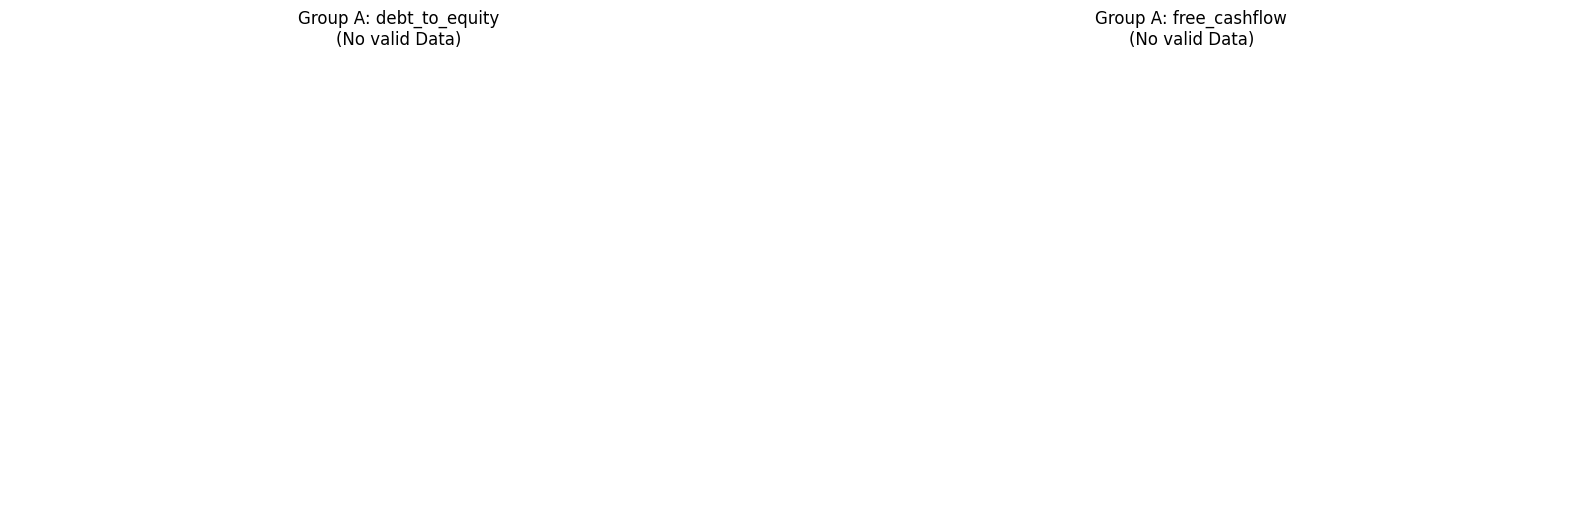

In [ ]:
metrics = ['debt_to_equity', 'free_cashflow']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    valid_df = group_a.copy()
    valid_df[metric] = pd.to_numeric(valid_df[metric], errors='coerce')
    valid_df[metric] = valid_df[metric].replace([np.inf, -np.inf], np.nan)
    valid_df = valid_df.dropna(subset=[metric])
    
    if metric == 'debt_to_equity':
        cap_val = 10000
        has_outliers = (valid_df[metric] > cap_val).any()
        valid_df[metric] = valid_df[metric].clip(upper=cap_val)
    
    valid_df = valid_df.sort_values(by=metric, ascending=True)
    
    if valid_df.empty:
        ax.set_title(f"Group A: {metric}\n(No valid Data)")
        ax.axis('off')
        continue
        
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    if metric == 'debt_to_equity':
        ax.set_title("Group A: Debt to Equity\n(Lower is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Debt to Equity (%)", fontsize=11)
        if has_outliers:
            ax.text(0.5, -0.4, "Values greater than 10,000% are capped", 
                    ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray', style='italic')
    else:
        ax.set_title("Group A: Free Cashflow\n(Higher is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Free Cashflow", fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    ax.axhline(0, color='black', linewidth=1.2)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.5
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        if metric == 'debt_to_equity':
            label_str = f"{yval:,.0f}%"
            if yval == cap_val and has_outliers:
                label_str += "*"
        else:
            label_str = f"{yval:,.0f}"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

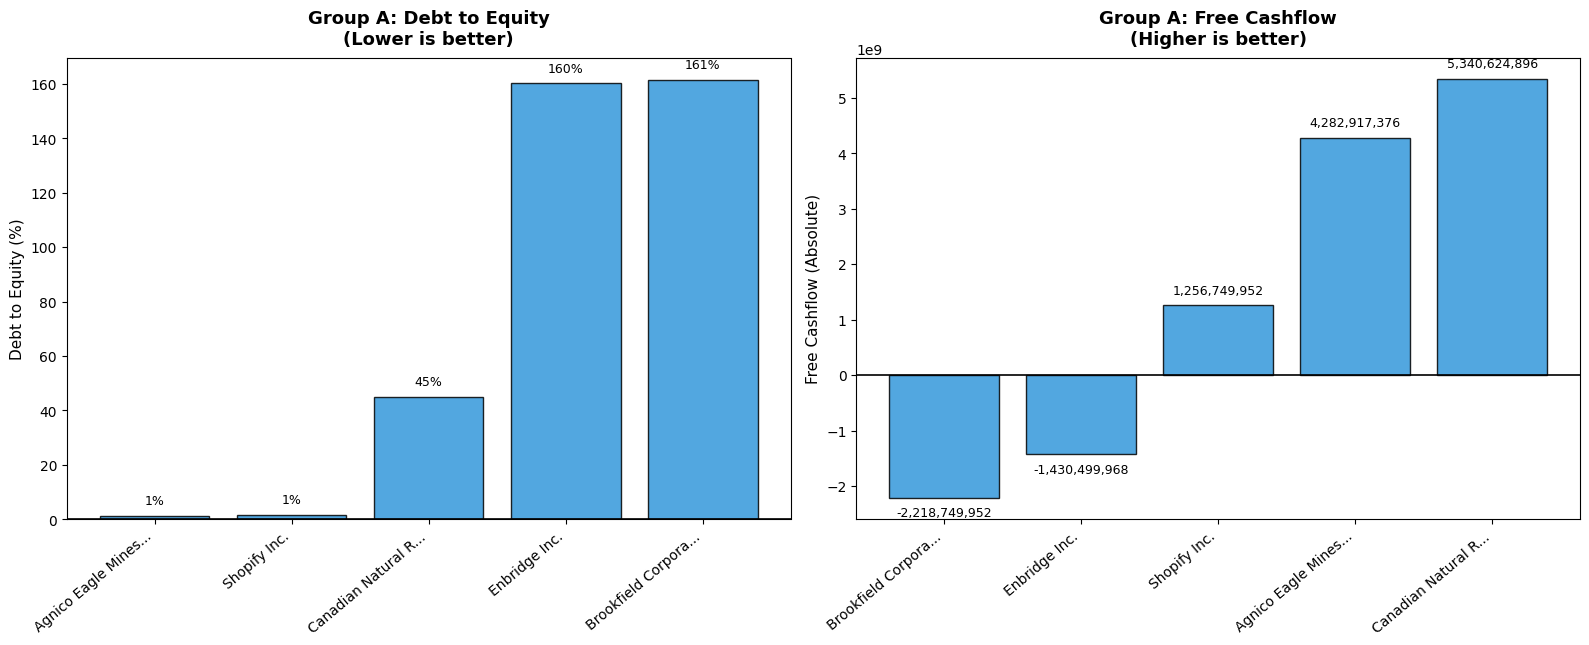

In [124]:

metrics = ['debt_to_equity', 'free_cashflow']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    valid_df = group_b.copy()
    valid_df[metric] = pd.to_numeric(valid_df[metric], errors='coerce')
    valid_df[metric] = valid_df[metric].replace([np.inf, -np.inf], np.nan)
    valid_df = valid_df.dropna(subset=[metric])
    
    if metric == 'debt_to_equity':
        cap_val = 10000
        has_outliers = (valid_df[metric] > cap_val).any()
        valid_df[metric] = valid_df[metric].clip(upper=cap_val)
    
    valid_df = valid_df.sort_values(by=metric, ascending=True)
    
    if valid_df.empty:
        ax.set_title(f"Group B: {metric}\n(No valid data)")
        ax.axis('off')
        continue
        
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    if metric == 'debt_to_equity':
        ax.set_title("Group A: Debt to Equity\n(Lower is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Debt to Equity (%)", fontsize=11)
        if has_outliers:
            ax.text(0.5, -0.4, "Values greater than 10,000% are capped ", 
                    ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray', style='italic')
    else:
        ax.set_title("Group A: Free Cashflow\n(Higher is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Free Cashflow (Absolute)", fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    ax.axhline(0, color='black', linewidth=1.2)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.5
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        if metric == 'debt_to_equity':
            label_str = f"{yval:,.0f}%"
            if yval == cap_val and has_outliers:
                label_str += "*"
        else:
            label_str = f"{yval:,.0f}"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

# Final Summary — Financial Analysis of The Bank of Nova Scotia (BNS)

## Company Selection
The Bank of Nova Scotia was selected from the Canadian geographic group as a representative 
of the large-cap Diversified Banks industry. The choice was motivated by BNS's strong 
institutional standing as one of Canada's Big Six banks, its international diversification 
into Latin America, and its stable profitability and dividend track record. 

## Profitability vs. Peers
The Bank of Nova Scotia is a profitable company. Both profit margins and return on equity are positive and at or above the peer median across all three groups. This is consistent across metrics, confirming earnings quality and suggesting that BNS's profitability is structurally secure. Within the Group B, margins are similar across the Big Six banks, reflecting the homogeneous regulatory environment and oligopolistic market structure.

## Valuation and Growth
BNS trades at below-median P/E and P/B multiples relative to global banking peers, pointing 
to a discounted valuation. However, BNS grows more slowly than many comparably sized companies, in line with the maturity of its core markets and the structural limitations of banking in a saturated domestic market. The valuation is therefore not an anomaly or a mispricing — it reflects a fair market assessment of BNS as a slow-growth, income-oriented financial institution.

## Debt and Free Cash Flow
BNS carries high leverage. The relevant benchmark is not an absolute D/E threshold but the peer comparison within the banking sector, where BNS's leverage is in line with 
the group median. Free cash flow is positive, supporting dividend sustainability and signaling 
healthy core operations. The overall financial profile is assessed as **mixed-to-strong**: 
leverage is high but regulated, and cash generation is sufficient to sustain distributions.

## Data Availability
The **return_on_assets** metric was available in the dataset but was not selected as one of the 
two required profitability metrics in this analysis; **profit_margins** and **return_on_equity** 
were used instead, as they provide a more complete picture of both income efficiency and 
capital productivity. No critical metrics were entirely unavailable for BNS itself; however, 
some peers in the comparison groups had missing values for specific metrics (particularly 
**pe_trailing**, **price_to_book**, and **revenue_growth**). These missing values reduced the size in some charts but did not compromise the analysis, as sufficient comparable data remained in each group.